# 01 · Introduction to Simulated Annealing

This notebook answers three questions:

1. **What problem does SA solve?**  
2. **Where does the name come from?** (the metallurgical analogy)  
3. **How does the acceptance probability work?**  

No code is needed to understand these ideas — we will visualize the key concepts interactively.

## 1  The Optimization Problem

We want to find the **global minimum** of a function $f: \mathbb{R}^d \to \mathbb{R}$:

$$x^* = \arg\min_{x \in \mathcal{X}} f(x)$$

The challenge: on **multimodal** landscapes $f$ has many local minima.  Purely greedy algorithms (hill-climbing, gradient descent) get trapped in the first one they encounter.

### The intuition: you're lost in a hilly landscape at night

Imagine you want to find the lowest valley but you can only see one step ahead.  A greedy approach always walks downhill — and ends up in whatever valley it starts near.  

SA's key idea: **occasionally accept a step uphill** (to a worse solution), allowing the search to escape local valleys and explore the broader landscape.  The probability of accepting a worse move decreases over time, just as cooling metal eventually "freezes" into a low-energy crystalline state.

## 2  The Metallurgical Analogy

**Annealing** in metallurgy:

1. Heat a metal until atoms are free to move (high energy, disordered).
2. Cool it **slowly** — atoms settle into a low-energy crystalline arrangement.
3. Cool it **fast** (quenching) — atoms get trapped in higher-energy disordered states.

The algorithm mirrors this:

| Metallurgy | Simulated Annealing |
|---|---|
| Temperature $T$ | Temperature parameter $T$ |
| Atom position | Candidate solution $x$ |
| System energy | Objective value $f(x)$ |
| Slow cooling | Gradual decrease of $T$ |
| Energy change $\Delta E$ | $\Delta f = f(x') - f(x)$ |
| Boltzmann acceptance | $P(\text{accept}) = e^{-\Delta f / T}$ |

## 3  The Acceptance Probability

At each step SA proposes a neighbour $x'$:

$$P(\text{accept } x') = \begin{cases} 1 & \text{if } f(x') \leq f(x) \\ e^{-(f(x') - f(x)) / T} & \text{otherwise} \end{cases}$$

Let's plot this as a function of $\Delta f = f(x') - f(x) > 0$ for different temperatures.

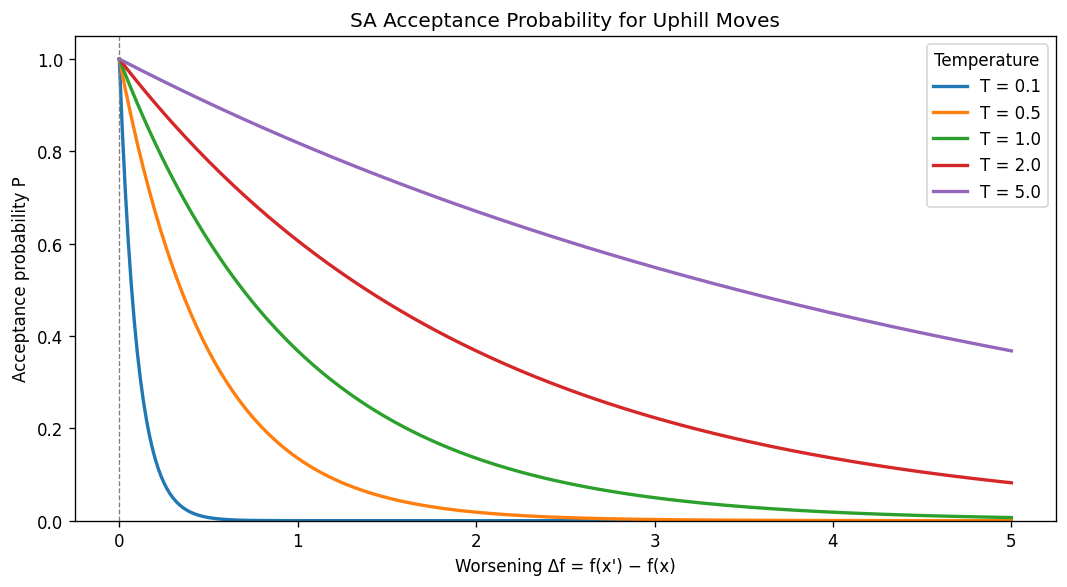

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

delta_f = np.linspace(0, 5, 300)
temperatures = [0.1, 0.5, 1.0, 2.0, 5.0]

fig, ax = plt.subplots(figsize=(9, 5))
for T in temperatures:
    prob = np.exp(-delta_f / T)
    ax.plot(delta_f, prob, linewidth=2, label=f"T = {T}")

ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel("Worsening Δf = f(x') − f(x)")
ax.set_ylabel("Acceptance probability P")
ax.set_title("SA Acceptance Probability for Uphill Moves")
ax.legend(title="Temperature")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

**Observations:**

- At **high T**: even large uphill moves are accepted with moderate probability → broad exploration.
- At **low T**: only tiny uphill moves are accepted → fine local search.
- At **T → 0**: SA becomes pure greedy hill-climbing (identical to gradient descent on discrete spaces).

This smooth transition from exploration to exploitation is what makes SA powerful.

## 4  The Algorithm in Pseudocode

```
x  ← random starting point within bounds
T  ← T_initial

while T > T_final:
    x'   ← neighbourhood(x, T)          # propose a neighbour
    Δf   ← f(x') − f(x)                 # change in objective
    
    if Δf ≤ 0:                           # improvement → always accept
        x ← x'
    elif rand() < exp(−Δf / T):          # uphill → accept with probability
        x ← x'
    
    T ← schedule(T)                      # cool down

return x, f(x)
```

Two algorithmic choices dominate performance:
1. **The cooling schedule** — how quickly T decreases.
2. **The neighbourhood function** — how far the proposed move can be from x.

## 5  A First Run on a Simple 1-D Problem

Let's verify the intuition by running SA on a 1-D multimodal function and watching where it goes.

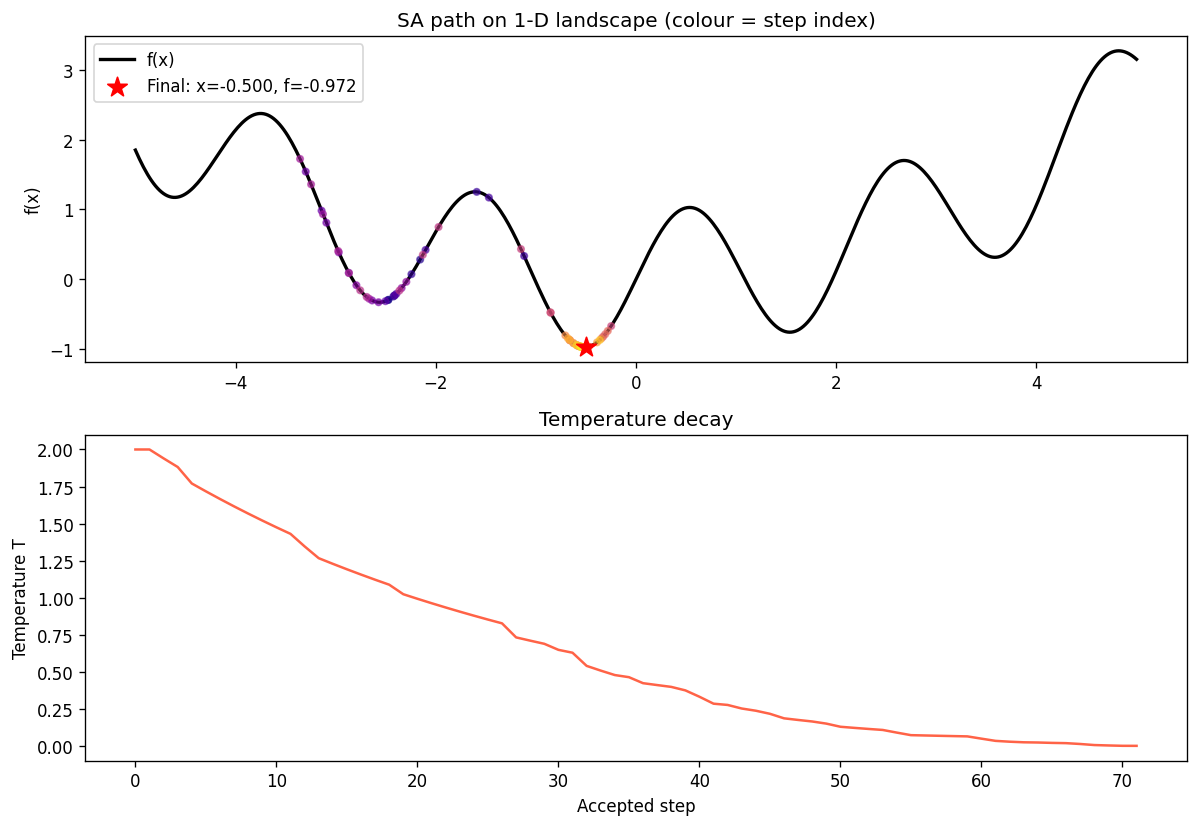

Found minimum at x = -0.4997, f(x) = -0.9725
Total function evaluations: 653


In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

from simulated_annealing import SimulatedAnnealing
from simulated_annealing.schedules import GeometricCooling
from simulated_annealing.neighbours import GaussianStep

# 1-D multimodal function:  f(x) = sin(3x) + x^2/10
def f_1d(x):
    return float(np.sin(3 * x[0]) + x[0]**2 / 10)

sa = SimulatedAnnealing(
    schedule=GeometricCooling(alpha=0.97),
    neighbourhood=GaussianStep(scale=0.5, seed=0),
    initial_temp=2.0,
    final_temp=1e-4,
)
result = sa.optimize(f_1d, bounds=[(-5.0, 5.0)])

# Plot the landscape and path
xs = np.linspace(-5, 5, 500)
ys = [f_1d([x]) for x in xs]
path_xs = [p[0] for p in result.path]
path_fs = [f_1d(p) for p in result.path]

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=False)

axes[0].plot(xs, ys, 'k-', linewidth=2, label='f(x)')
axes[0].scatter(path_xs, path_fs, c=range(len(path_xs)), cmap='plasma',
                s=15, alpha=0.6, zorder=3)
axes[0].scatter(result.solution[0], result.value, color='red', s=150,
                marker='*', zorder=5, label=f'Final: x={result.solution[0]:.3f}, f={result.value:.3f}')
axes[0].set_ylabel('f(x)')
axes[0].set_title('SA path on 1-D landscape (colour = step index)')
axes[0].legend()

axes[1].plot(result.temperatures, color='tomato', linewidth=1.5)
axes[1].set_xlabel('Accepted step')
axes[1].set_ylabel('Temperature T')
axes[1].set_title('Temperature decay')

plt.tight_layout()
plt.show()
print(f"Found minimum at x = {result.solution[0]:.4f}, f(x) = {result.value:.4f}")
print(f"Total function evaluations: {result.n_evaluations}")

## Summary

| Concept | Key point |
|---|---|
| SA is a **metaheuristic** | No gradient required; works on any black-box function |
| Acceptance probability | $e^{-\Delta f / T}$ balances exploration vs. exploitation |
| Cooling schedule | Determines how fast T decreases; crucial for performance |
| Neighbourhood function | Determines step size; interacts with cooling schedule |

➡ **Next:** [02_loss_landscapes.ipynb](02_loss_landscapes.ipynb) — visualising the 3 benchmark functions.